# 04 Analysis and Figures

This notebook turns APFD outputs into tables and simple figures for the report.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from d4j_lang_utils import PROJECT_ROOT

DATA_DIR = PROJECT_ROOT / 'data'
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

results = pd.read_csv(DATA_DIR / 'lang_apfd_results.csv')
results.head()


,bug_id,method,apfd,num_tests,num_triggering
0,1,Random,0.375,4,1
1,1,FailureHistory,0.625,4,1
2,1,ChangeFrequency,0.875,4,1
3,1,ComplexityOnly,0.875,4,1
4,1,Proposed,0.875,4,1


In [2]:
summary = results.groupby('method', as_index=False)['apfd'].agg(['mean', 'median', 'std']).reset_index()
summary


,index,method,mean,median,std
0,0,ChangeFrequency,0.806944,0.875000,0.163217
1,1,ComplexityOnly,0.806944,0.875000,0.163217
2,2,FailureHistory,0.534722,0.562500,0.315648
3,3,Proposed,0.794444,0.875000,0.162209
4,4,Random,0.432639,0.444444,0.198239


In [3]:
pivot = results.pivot(index='bug_id', columns='method', values='apfd').reset_index()
pivot


method,bug_id,ChangeFrequency,ComplexityOnly,FailureHistory,Proposed,Random
0,1,0.875000,0.875000,0.625000,0.875000,0.375000
1,3,0.875000,0.875000,0.875000,0.875000,0.125000
2,4,0.875000,0.875000,0.125000,0.875000,0.375000
3,5,0.500000,0.500000,0.500000,0.500000,0.500000
4,6,0.944444,0.944444,0.722222,0.944444,0.388889
5,7,0.875000,0.875000,0.875000,0.875000,0.125000
6,8,0.875000,0.875000,0.125000,0.875000,0.687500
7,9,0.875000,0.875000,0.125000,0.750000,0.562500
8,10,0.875000,0.875000,0.875000,0.875000,0.687500
9,11,0.500000,0.500000,0.500000,0.500000,0.500000


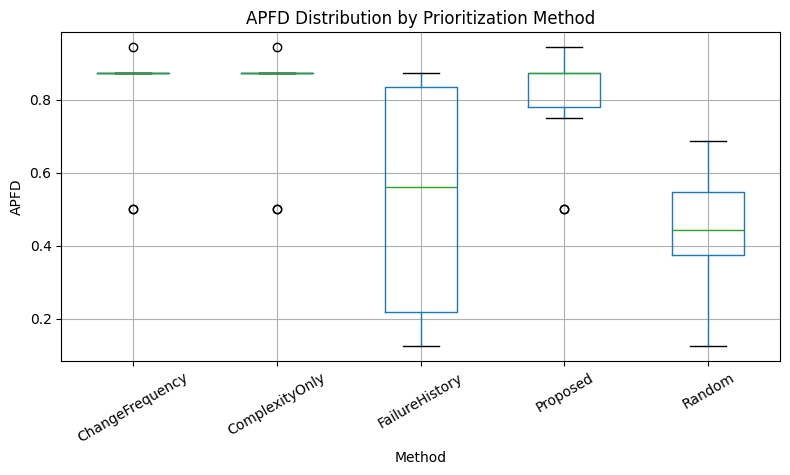

In [4]:
results.boxplot(column='apfd', by='method', rot=30, figsize=(8, 5))
plt.suptitle('')
plt.title('APFD Distribution by Prioritization Method')
plt.xlabel('Method')
plt.ylabel('APFD')
plt.tight_layout()
plt.savefig(FIG_DIR / 'apfd_boxplot.png', dpi=200)
plt.show()
